In [32]:
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns  
import numpy as np 
import matplotlib.ticker as mticker
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import pandas as pd

In [97]:
df = pd.read_csv('/kaggle/input/e-commerce-customer-for-behavior-analysis/ecommerce_customer_data_large.csv')
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [98]:
customer_data = df[df['Customer ID'] == 44605]
print(customer_data)

   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        44605  2023-05-03 21:30:02             Home            177         1   
1        44605  2021-05-16 13:57:44      Electronics            174         3   
2        44605  2020-07-13 06:16:57            Books            413         1   
3        44605  2023-01-17 13:14:36      Electronics            396         3   
4        44605  2021-05-01 11:29:27            Books            259         4   

   Total Purchase Amount Payment Method  Customer Age  Returns Customer Name  \
0                   2427         PayPal            31      1.0   John Rivera   
1                   2448         PayPal            31      1.0   John Rivera   
2                   2345    Credit Card            31      1.0   John Rivera   
3                    937           Cash            31      0.0   John Rivera   
4                   2598         PayPal            31      1.0   John Rivera   

   Age  Gender  Churn  
0   31  

In [119]:
features = ['Customer ID','Total Purchase Amount', 'Quantity', 'Customer Age','Gender']

df_cluster = df[features].copy()
df_cluster['Gender'] = df_cluster['Gender'].map({'Female': 0, 'Male': 1})


In [120]:
import pandas as pd

# Sample dataframe (you can skip this part if you already have df)
# df = pd.read_csv("your_data.csv")  # If you're loading from a CSV


# Group by Customer ID and aggregate
df_agg = df_cluster.groupby('Customer ID').agg({
    'Total Purchase Amount': 'sum',
    'Quantity': 'sum',
    'Customer Age': 'first',
    'Gender': 'first',
})


In [121]:
df_cluster = df_agg

In [122]:
df_agg.head()

,Total Purchase Amount,Quantity,Customer Age,Gender
Customer ID,,,,
1,6290,15,67,0
2,16481,18,42,0
3,9423,15,31,1
4,7826,19,37,1
5,9769,13,24,0


In [123]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels, sample_size=5000, random_state=42)
    silhouette_scores.append(score)


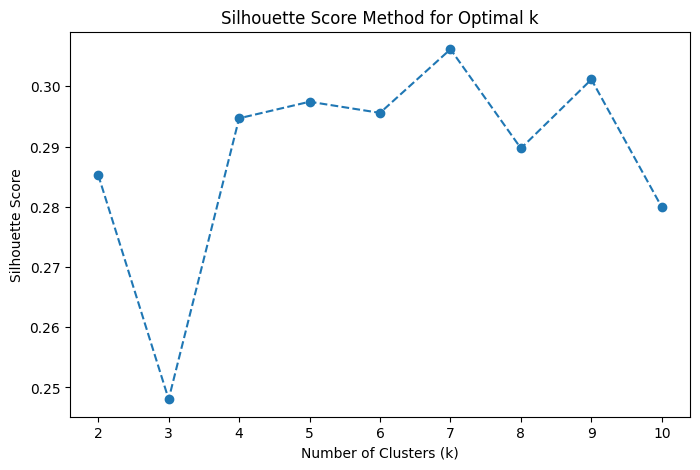

Best k based on silhouette score: 7


In [124]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='--')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Method for Optimal k")
plt.show()

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Best k based on silhouette score: {best_k}")


In [126]:
kmeans = MiniBatchKMeans(n_clusters=6, random_state=42, batch_size=1000, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(df_scaled)


In [127]:
cluster_summary = df_cluster.groupby('Cluster').mean()
print(cluster_summary)


         Total Purchase Amount   Quantity  Customer Age    Gender
Cluster                                                          
0                 10869.117168  12.430456     30.709311  0.000000
1                  8060.752625   9.199389     34.810256  1.000000
2                 18387.546034  20.602408     33.743768  1.000000
3                 24010.320718  26.088706     46.833358  0.199102
4                 11440.502873  12.342099     58.065635  0.000000
5                 13077.518169  13.887282     59.558331  1.000000


* cluster 0 Young low spenders high quantities 

* cluster 1 old high spenders avg quantites

* cluster 2 young avg spenders low quantites

* cluster 3 old avg spenders high quantites

* champions
High value, highly engaged customers with frequent purchases
cluster 4 young high spenders high quantities

*At Risk
cluster 5 old low spenders low qantities

In [128]:
import joblib
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [129]:
joblib.dump(kmeans, 'kmeans.pkl')

['kmeans.pkl']

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

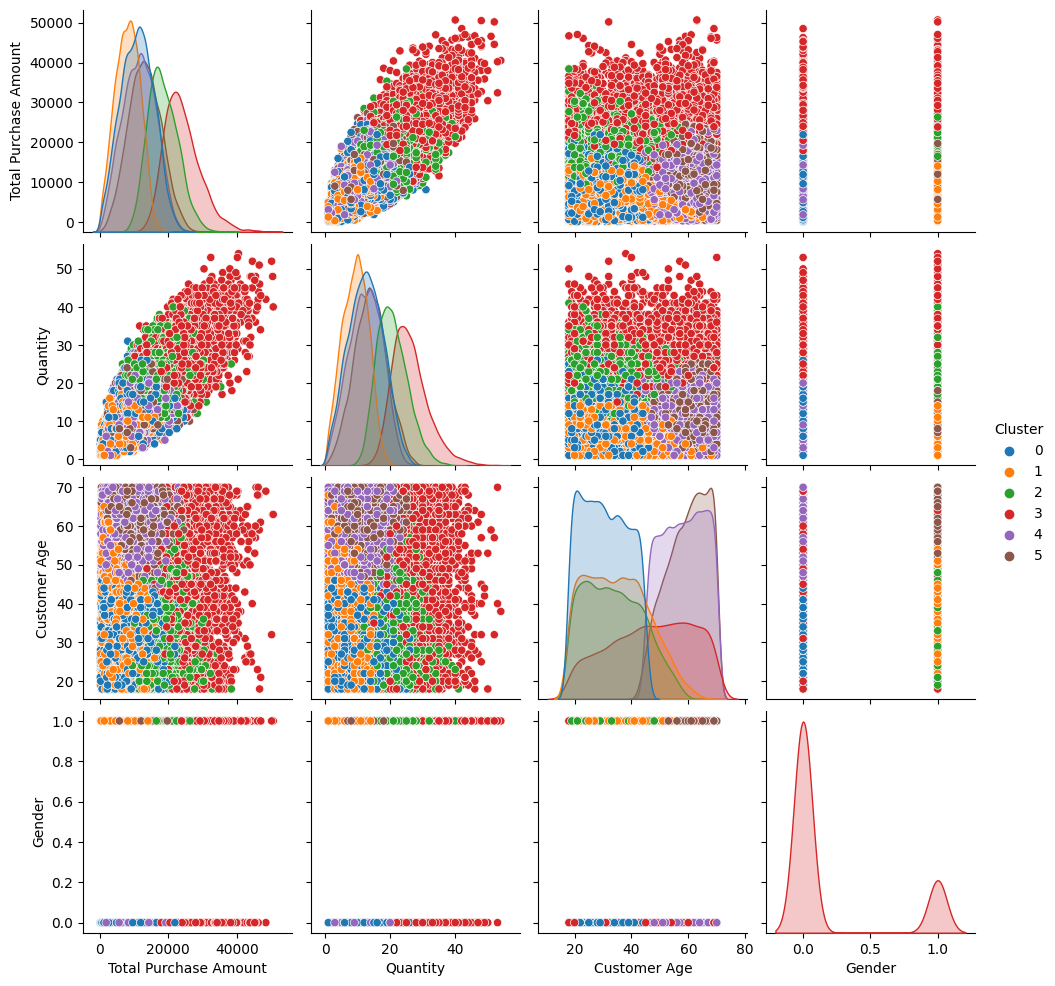

In [131]:
sns.pairplot(df_cluster, hue='Cluster', palette='tab10', diag_kind='kde')
plt.show()


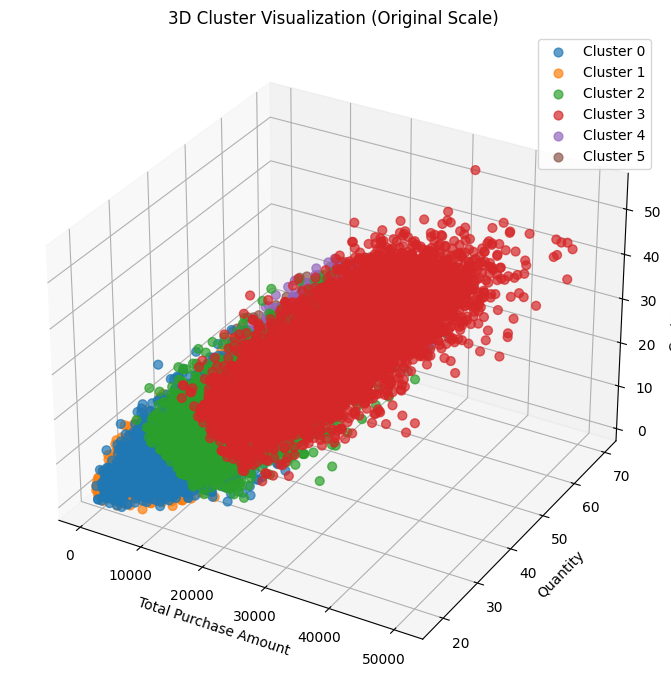

In [132]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Prepare the figure and 3D axes
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for each cluster
for cluster in sorted(df_cluster['Cluster'].unique()):
    cluster_data = df_cluster[df_cluster['Cluster'] == cluster]
    ax.scatter(
        cluster_data['Total Purchase Amount'],
        cluster_data['Customer Age'],
        cluster_data['Quantity'],
        label=f'Cluster {cluster}',
        s=40,  # point size
        alpha=0.7
    )

# Label axes
ax.set_xlabel('Total Purchase Amount')
ax.set_ylabel('Quantity')
ax.set_zlabel('Customer Age')
ax.set_title('3D Cluster Visualization (Original Scale)')

# Show legend and plot
ax.legend()
plt.tight_layout()
plt.show()


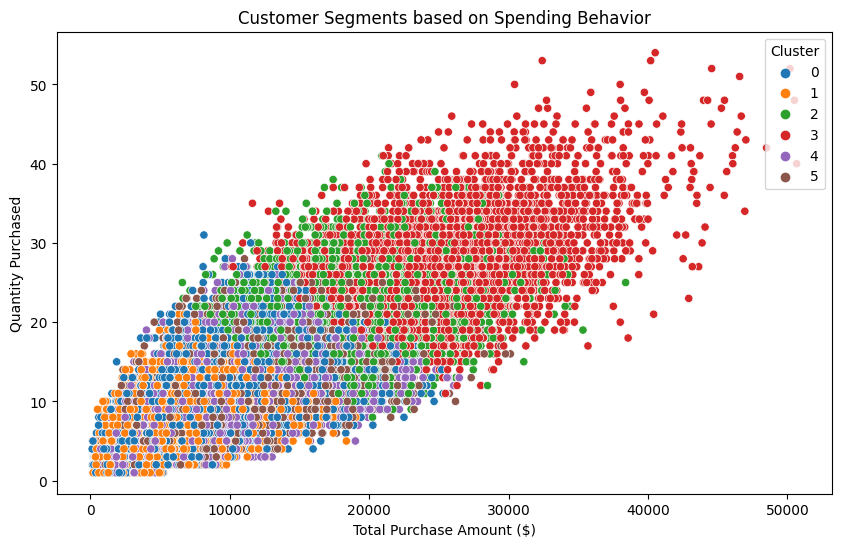

In [133]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df_cluster['Total Purchase Amount'], 
                y=df_cluster['Quantity'], 
                hue=df_cluster['Cluster'], 
                palette='tab10')
plt.xlabel("Total Purchase Amount ($)")
plt.ylabel("Quantity Purchased")
plt.title("Customer Segments based on Spending Behavior")
plt.legend(title="Cluster", loc="upper right")
plt.show()


In [135]:
df_cluster["Cluster"].value_counts()


Cluster
0    10310
4     9050
5     8366
1     8190
2     7060
3     6685
Name: count, dtype: int64